# Machine Learning Fundamentals

# Week 2 – Predict Titanic Survival Using Logistic Regression

**Dataset:** Titanic – Machine Learning from Disaster

**Prepared by:** Abdul Raheem

**Track:** Neurofive Machine Learning Fundamentals Track

# Introduction

After performing Exploratory Data Analysis and cleaning the Titanic dataset in Week 1, the next step is to develop a Machine Learning model capable of predicting passenger survival.

This task introduces Logistic Regression, a supervised classification algorithm used to predict binary outcomes. The objective is to preprocess the dataset, train a classification model, evaluate its performance, and interpret the prediction results using a confusion matrix.

# Objectives

- Load the cleaned Titanic dataset
- Encode categorical features
- Split the dataset into training and testing sets
- Train a Logistic Regression classifier
- Predict passenger survival
- Evaluate model accuracy
- Generate and interpret a confusion matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [7]:
df = pd.read_csv(r"D:\Machine Learning Fundamentals Course\Week 1\titanic\train.csv")

# Dataset Overview

Before training the model, the dataset is inspected to verify its structure and identify any remaining missing values.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Handling Missing Values

The same preprocessing approach from Week 1 is applied to ensure the dataset is complete before model training.

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Cabin"] = df["Cabin"].fillna("Unknown")

# Encoding Categorical Features

Machine Learning models cannot process text directly. Therefore, categorical variables are converted into numerical values using one-hot encoding.

In [10]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

# Selecting Features and Target Variable

The target variable is **Survived**, while the remaining selected attributes are used as predictor variables.

In [11]:
X = df.drop(["Survived","Name","Ticket","Cabin","PassengerId"], axis=1)

y = df["Survived"]

# Splitting the Dataset

The dataset is divided into training and testing subsets using an 80:20 ratio.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Training the Logistic Regression Model

The Logistic Regression classifier is trained using the training dataset.

In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

# Making Predictions

The trained model is used to predict passenger survival on the testing dataset.

In [16]:
y_pred = model.predict(X_test)

# Model Accuracy

Accuracy measures the proportion of correctly classified passengers.

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


# Confusion Matrix

The confusion matrix summarizes the classification results by comparing predicted labels with actual labels.

In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[90 15]
 [19 55]]


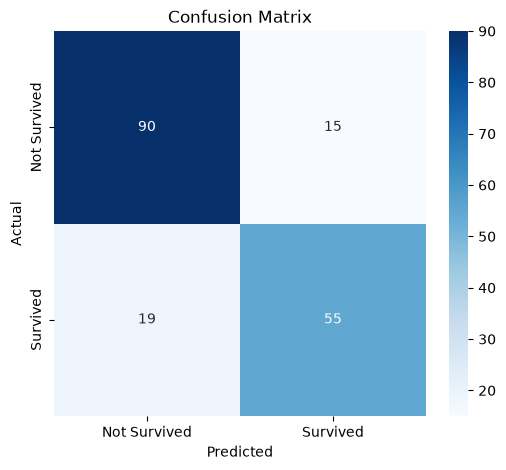

In [19]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Not Survived","Survived"],
            yticklabels=["Not Survived","Survived"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Confusion Matrix Interpretation

The confusion matrix shows how many passengers were correctly and incorrectly classified.

- True Positives represent passengers who survived and were correctly predicted.
- True Negatives represent passengers who did not survive and were correctly predicted.
- False Positives indicate passengers incorrectly predicted to survive.
- False Negatives indicate passengers who survived but were predicted not to survive.

A good classification model aims to maximize true predictions while minimizing false predictions.

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Conclusion

A Logistic Regression classifier was successfully trained to predict Titanic passenger survival.

Categorical variables were encoded using one-hot encoding, and the dataset was divided into training and testing subsets. The trained model achieved satisfactory classification accuracy, demonstrating that Logistic Regression provides a simple yet effective baseline model for binary classification problems.

The confusion matrix further illustrates the strengths and limitations of the model by highlighting correctly and incorrectly classified instances.